In [1]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
BASE_DIR = Path().cwd().parent


In [5]:
df = pd.read_parquet(BASE_DIR / "data" / "raw" / "weather_historical" / "year=2023.parquet")

In [24]:
df = pd.read_parquet(BASE_DIR / "data" / "raw" / "swiss_load_2020.parquet")

In [25]:
df

,timestamp_utc,load_mw
0,2020-01-01 00:00:00+00:00,7012.49
1,2020-01-01 01:00:00+00:00,7134.25
2,2020-01-01 02:00:00+00:00,6972.69
3,2020-01-01 03:00:00+00:00,7580.84
4,2020-01-01 04:00:00+00:00,7179.81
...,...,...
8779,2020-12-31 19:00:00+00:00,7667.92
8780,2020-12-31 20:00:00+00:00,7314.95
8781,2020-12-31 21:00:00+00:00,7213.00
8782,2020-12-31 22:00:00+00:00,7403.85


In [14]:
df_pivot = df.pivot_table(
    index="timestamp_utc",
    columns="city",
    values="temperature_2m",
    aggfunc="mean",
)

In [15]:
df_pivot

city,Basel,Bern,Central_CH,Geneva,Interlaken,Lausanne,Lucerne,Lugano,St_Gallen,Zurich
timestamp_utc,,,,,,,,,,
2023-01-01 00:00:00+00:00,10.70,5.05,4.266,7.95,9.335,9.297000,11.6585,9.155,10.50,7.75
2023-01-01 01:00:00+00:00,10.40,4.45,4.416,8.40,7.535,9.146999,10.1585,9.755,9.30,8.60
2023-01-01 02:00:00+00:00,8.95,4.35,4.466,8.30,7.785,9.297000,10.6085,8.705,9.70,7.50
2023-01-01 03:00:00+00:00,10.35,4.90,4.116,8.10,8.535,9.347000,11.0085,8.905,8.70,8.40
2023-01-01 04:00:00+00:00,11.40,4.75,3.816,7.70,7.285,9.097000,9.8085,9.155,8.00,8.05
...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00+00:00,5.15,1.55,-2.184,4.65,4.035,3.547000,5.3085,6.255,1.90,1.95
2023-12-31 20:00:00+00:00,5.10,0.50,-2.884,2.75,3.035,2.897000,5.2585,5.905,1.55,1.55
2023-12-31 21:00:00+00:00,4.50,0.25,-5.384,2.05,2.835,2.497000,4.8585,5.555,1.35,1.50


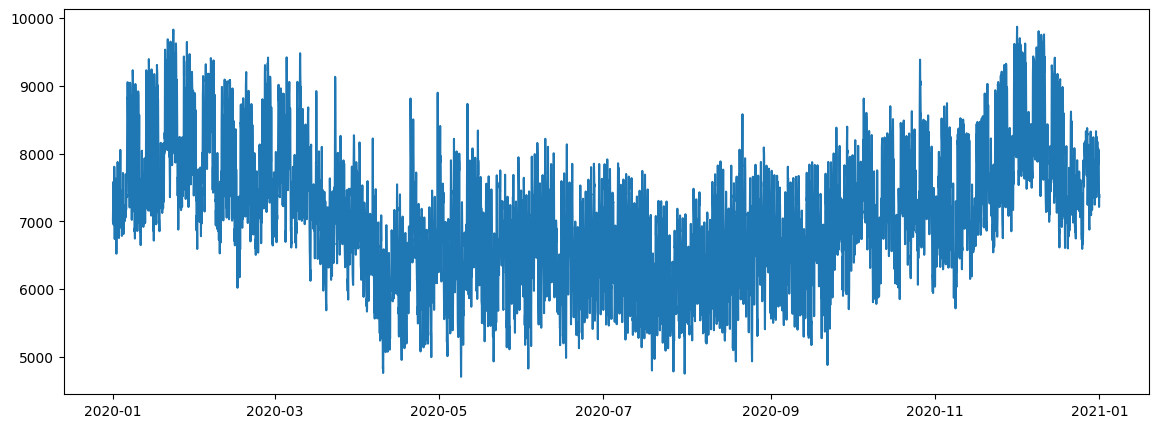

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp_utc"], df["load_mw"])

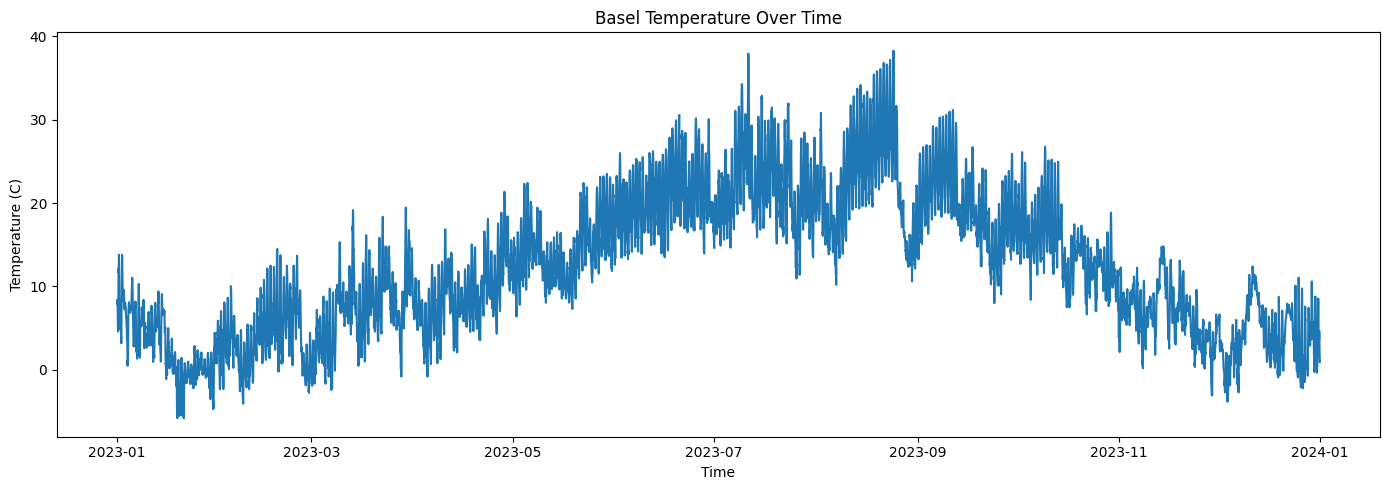

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(df_pivot.index, df_pivot["Geneva"])

plt.title("Basel Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.tight_layout()
plt.show()